Build classification and Regression Model

Planning to remove late_canc_reason, from_actual_arrival_min , from_actual_departure_min , to_actual_arrival_min,  to_actual_departure_min, propagated_delay_min, end_segment_delay_min, cum_delay_min , prev_train_leg_delay_min , prev_train_cum_delay_min , prev_train_end_segment_delay_min , historical_avg_propagated_delay_min , historical_avg_cum_delay_min , historical_avg_arrival_delay_min , delay_historical_difference


---

Removing this because they will result in the model overfitting the training dataset as these information wont be availabvle

From arrival delay col dodf["delayed"] = (df["arrival_delay_min"] >= 10).astype(int)

In [1]:
import pandas as pd
import plotly.express as px
import numpy as np

In [2]:
pd.set_option('display.float_format', '{:.2f}'.format)
df = pd.read_csv("/content/drive/MyDrive/DSLPF/final-segment-dataset-2025.csv")

df.head()

,rid,from_station,to_station,late_canc_reason,total_stops_in_run,remaining_stops_after_this,date_of_service,month,day_of_week,day_of_month,...,historical_avg_leg_duration_min,historical_avg_cum_delay_min,historical_avg_arrival_delay_min,delay_historical_difference,from_temp,from_rain,from_wind,to_temp,to_rain,to_wind
0,202501000000000.00,KGX,YRK,696.00,6,5,01/01/2025,1,2,1,...,106.66,-62.20,-65.83,61.20,6.10,0.80,17.00,4.10,0.00,17.90
1,202501000000000.00,KGX,YRK,NaN,6,5,01/01/2025,1,2,1,...,106.66,-62.20,-65.83,61.20,5.90,1.20,16.90,3.90,0.00,17.20
2,202501000000000.00,KGX,YRK,NaN,6,5,01/01/2025,1,2,1,...,106.66,-62.20,-65.83,61.20,6.20,0.20,14.90,3.40,0.00,15.40
3,202501000000000.00,KGX,YRK,NaN,6,5,02/01/2025,1,3,2,...,106.66,-62.20,-65.83,61.20,3.10,0.00,8.10,0.20,0.00,11.00
4,202501000000000.00,KGX,YRK,NaN,6,5,02/01/2025,1,3,2,...,106.66,-62.20,-65.83,61.20,2.40,0.00,6.70,0.00,0.00,12.30


In [3]:
df.shape

(11195, 38)

In [4]:
#numerical columns
df.describe()

,rid,late_canc_reason,total_stops_in_run,remaining_stops_after_this,month,day_of_week,day_of_month,from_sched_arrival_min,from_actual_arrival_min,from_sched_departure_min,...,historical_avg_leg_duration_min,historical_avg_cum_delay_min,historical_avg_arrival_delay_min,delay_historical_difference,from_temp,from_rain,from_wind,to_temp,to_rain,to_wind
count,11195.00,3721.00,11195.00,11195.00,11195.00,11195.00,11195.00,11195.00,11195.00,11195.00,...,11136.00,11136.00,11136.00,11136.00,11195.00,11195.00,11195.00,11195.00,11195.00,11195.00
mean,202506392764627.06,765.55,9.16,4.58,6.39,1.99,15.60,1042.49,1033.37,1187.20,...,28.82,-187.20,-61.54,41.83,11.40,0.06,12.28,10.77,0.06,12.24
std,3394574883.53,134.35,2.30,2.69,3.39,1.42,8.70,420.57,438.03,105.65,...,27.15,126.15,35.68,143.14,6.69,0.35,6.92,6.32,0.36,7.35
min,202501000000000.00,501.00,4.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,...,-115.86,-1069.00,-189.44,-1265.00,-26.80,0.00,0.00,-26.80,0.00,0.00
25%,202503000000000.00,650.00,6.00,2.00,3.00,1.00,8.00,1112.00,1113.00,1127.00,...,13.20,-253.16,-76.52,32.57,6.60,0.00,7.20,6.30,0.00,6.80
50%,202506000000000.00,828.00,10.00,4.00,6.00,2.00,16.00,1187.00,1195.00,1194.00,...,23.37,-179.30,-60.26,53.84,11.60,0.00,11.30,11.00,0.00,11.00
75%,202509000000000.00,887.00,11.00,7.00,9.00,3.00,23.00,1257.00,1262.00,1259.00,...,37.04,-89.43,-30.94,67.59,15.80,0.00,16.00,15.00,0.00,16.20
max,202512000000000.00,921.00,14.00,13.00,12.00,4.00,31.00,1391.00,1438.00,1391.00,...,1195.00,132.00,66.00,1133.00,32.40,7.20,60.10,31.50,7.20,61.20


In [5]:
#Creating target variable
df["Delayed"] = (df["arrival_delay_min"] >= 10).astype(int)

In [6]:
df.Delayed

,Delayed
0,1
1,0
2,0
3,0
4,0
...,...
11190,0
11191,0
11192,0
11193,0


In [7]:
#Column names
list(df.columns)

['rid',
 'from_station',
 'to_station',
 'late_canc_reason',
 'total_stops_in_run',
 'remaining_stops_after_this',
 'date_of_service',
 'month',
 'day_of_week',
 'day_of_month',
 'from_sched_arrival_min',
 'from_actual_arrival_min',
 'from_sched_departure_min',
 'from_actual_departure_min',
 'to_sched_arrival_min',
 'to_actual_arrival_min',
 'to_sched_departure_min',
 'to_actual_departure_min',
 'propagated_delay_min',
 'end_segment_delay_min',
 'cum_delay_min',
 'leg_duration_min',
 'arrival_delay_min',
 'prev_train_leg_delay_min',
 'prev_train_cum_delay_min',
 'prev_train_segment_duration_min',
 'prev_train_end_segment_delay_min',
 'historical_avg_propagated_delay_min',
 'historical_avg_leg_duration_min',
 'historical_avg_cum_delay_min',
 'historical_avg_arrival_delay_min',
 'delay_historical_difference',
 'from_temp',
 'from_rain',
 'from_wind',
 'to_temp',
 'to_rain',
 'to_wind',
 'Delayed']

In [8]:
#Dropping variables
classification_df = df.drop(columns=(["late_canc_reason","from_actual_arrival_min", "from_actual_departure_min", "to_actual_arrival_min", "to_actual_departure_min", "propagated_delay_min",
                                      "end_segment_delay_min", "cum_delay_min", "prev_train_leg_delay_min", "prev_train_cum_delay_min", "prev_train_end_segment_delay_min",
                                      "historical_avg_propagated_delay_min", "historical_avg_cum_delay_min", "historical_avg_arrival_delay_min", "delay_historical_difference",
                                      "arrival_delay_min","historical_avg_leg_duration_min","leg_duration_min","rid","from_station","to_station","date_of_service"]))

In [9]:
list(classification_df.columns)

['total_stops_in_run',
 'remaining_stops_after_this',
 'month',
 'day_of_week',
 'day_of_month',
 'from_sched_arrival_min',
 'from_sched_departure_min',
 'to_sched_arrival_min',
 'to_sched_departure_min',
 'prev_train_segment_duration_min',
 'from_temp',
 'from_rain',
 'from_wind',
 'to_temp',
 'to_rain',
 'to_wind',
 'Delayed']

In [10]:
#Checking for errors
classification_df.describe()

,total_stops_in_run,remaining_stops_after_this,month,day_of_week,day_of_month,from_sched_arrival_min,from_sched_departure_min,to_sched_arrival_min,to_sched_departure_min,prev_train_segment_duration_min,from_temp,from_rain,from_wind,to_temp,to_rain,to_wind,Delayed
count,11195.00,11195.00,11195.00,11195.00,11195.00,11195.00,11195.00,11195.00,11195.00,11153.00,11195.00,11195.00,11195.00,11195.00,11195.00,11195.00,11195.00
mean,9.16,4.58,6.39,1.99,15.60,1042.49,1187.20,1224.13,1042.59,29.51,11.40,0.06,12.28,10.77,0.06,12.24,0.20
std,2.30,2.69,3.39,1.42,8.70,420.57,105.65,91.27,423.50,98.89,6.69,0.35,6.92,6.32,0.36,7.35,0.40
min,4.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,-1427.00,-26.80,0.00,0.00,-26.80,0.00,0.00,0.00
25%,6.00,2.00,3.00,1.00,8.00,1112.00,1127.00,1164.00,1115.00,19.00,6.60,0.00,7.20,6.30,0.00,6.80,0.00
50%,10.00,4.00,6.00,2.00,16.00,1187.00,1194.00,1220.00,1194.00,26.00,11.60,0.00,11.30,11.00,0.00,11.00,0.00
75%,11.00,7.00,9.00,3.00,23.00,1257.00,1259.00,1291.00,1259.00,42.00,15.80,0.00,16.00,15.00,0.00,16.20,0.00
max,14.00,13.00,12.00,4.00,31.00,1391.00,1391.00,1417.00,1391.00,1334.00,32.40,7.20,60.10,31.50,7.20,61.20,1.00


In [11]:
outlier_identifier = px.box(classification_df, x='to_wind')

outlier_identifier.show()

Prev_train_segment_duration_min normal range should be 0 - 319


In [12]:
classification_df = classification_df[(classification_df['prev_train_segment_duration_min'] >= 0) & (classification_df['prev_train_segment_duration_min'] <= 319)]

print(f"Shape of DataFrame after filtering: {classification_df.shape}")

Shape of DataFrame after filtering: (11101, 17)


In [13]:
classification_df.describe()

,total_stops_in_run,remaining_stops_after_this,month,day_of_week,day_of_month,from_sched_arrival_min,from_sched_departure_min,to_sched_arrival_min,to_sched_departure_min,prev_train_segment_duration_min,from_temp,from_rain,from_wind,to_temp,to_rain,to_wind,Delayed
count,11101.00,11101.00,11101.00,11101.00,11101.00,11101.00,11101.00,11101.00,11101.00,11101.00,11101.00,11101.00,11101.00,11101.00,11101.00,11101.00,11101.00
mean,9.16,4.59,6.40,1.99,15.63,1042.14,1187.23,1224.21,1045.79,34.91,11.41,0.06,12.27,10.79,0.06,12.24,0.20
std,2.30,2.68,3.39,1.42,8.69,420.84,105.03,89.58,420.37,26.60,6.70,0.35,6.93,6.31,0.36,7.35,0.40
min,4.00,1.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,-26.80,0.00,0.00,-26.80,0.00,0.00,0.00
25%,6.00,2.00,4.00,1.00,8.00,1112.00,1127.00,1164.00,1115.00,19.00,6.70,0.00,7.20,6.40,0.00,6.80,0.00
50%,10.00,4.00,6.00,2.00,16.00,1187.00,1194.00,1220.00,1194.00,26.00,11.70,0.00,11.30,11.00,0.00,11.00,0.00
75%,11.00,7.00,9.00,3.00,23.00,1257.00,1259.00,1291.00,1259.00,42.00,15.80,0.00,15.90,15.00,0.00,16.20,0.00
max,14.00,13.00,12.00,4.00,31.00,1391.00,1391.00,1417.00,1371.00,319.00,32.40,7.20,60.10,31.50,7.20,61.20,1.00


Classification Model part

---



In [14]:
#To construct and plot decision trees
from sklearn import tree
from matplotlib import pyplot as plt

#Import Decision Tree Classifier to predict loan approval status
from sklearn.tree import DecisionTreeClassifier


#To optimise the Decision Tree model's hyperparameters
from sklearn.model_selection import GridSearchCV

#Import scikit-learn metrics module for classification and regression performance metrics
from sklearn import metrics

# To create and plot the confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# To produce the classification metrics report
from sklearn.metrics import classification_report

# To create, calculate and plot the RoC curve
from sklearn.metrics import RocCurveDisplay


In [15]:
#Splitting into X and Y
X = classification_df.drop('Delayed', axis=1)
y = classification_df['Delayed']

In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X1 = scaler.fit_transform(X)

In [17]:
from sklearn.model_selection import train_test_split


# Split the dataset in 60% Training and 40% Test with class stratification
X1_train, X1_test, y_train, y_test = train_test_split(X1, y, test_size=0.2, random_state=43, stratify=y)


In [18]:
print('Whole Data shape', classification_df.shape)
print('X_train shape', X1_train.shape)
print('X_test shape', X1_test.shape)


Whole Data shape (11101, 17)
X_train shape (8880, 16)
X_test shape (2221, 16)


In [19]:
# Build a fully grown decision tree clf
clf = DecisionTreeClassifier()
clf.fit(X1_train, y_train)

#To make predictions on the test set, ues the predict method:
y_pred_clf = clf.predict(X1_test)


In [20]:
# To find the full depth of the decision tree
print(clf.tree_.max_depth)


32


In [21]:
# Create Decision Tree classifer object
clf_pruned = DecisionTreeClassifier(max_depth = 4)

# Train Decision Tree Classifer
clf_pruned = clf_pruned.fit(X1_train,y_train)

#Predict the response for test dataset
y_pred_clf_pruned = clf_pruned.predict(X1_test)


clf fully grown tree report 
               precision    recall  f1-score   support

           0       0.88      0.87      0.87      1778
           1       0.49      0.51      0.50       443

    accuracy                           0.79      2221
   macro avg       0.68      0.69      0.68      2221
weighted avg       0.80      0.79      0.80      2221



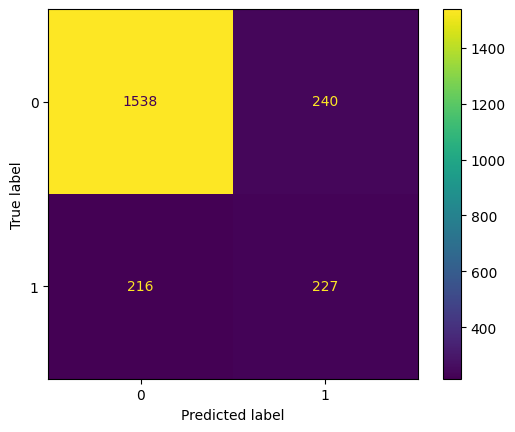

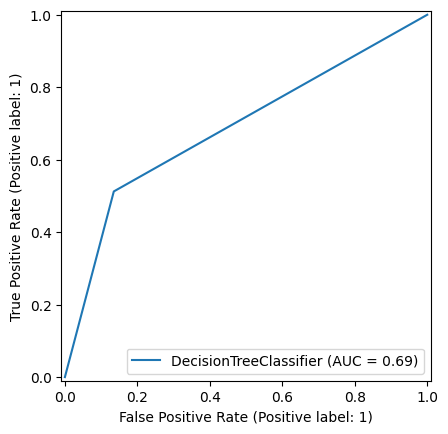

In [22]:
# Construct and plot the confusion matrix for the fuly-grown tree (clf model)
clf_cm_test = confusion_matrix(y_test, y_pred_clf, labels=clf.classes_ )
disp = ConfusionMatrixDisplay(clf_cm_test,display_labels=clf.classes_   )
disp.plot(values_format = '.0f') # value_format = .0f expands the scientific notation e inside the confusion matrix

# Produce the classification report for the fuly-grown tree (clf model)
print("clf fully grown tree report \n", classification_report(y_test, y_pred_clf))

# Plot the ROC curve for the fully-grown treen
clf_Roc = RocCurveDisplay.from_estimator(clf, X1_test, y_test)


clf_pruned tree report 
               precision    recall  f1-score   support

           0       0.81      0.99      0.89      1778
           1       0.64      0.06      0.11       443

    accuracy                           0.81      2221
   macro avg       0.73      0.53      0.50      2221
weighted avg       0.78      0.81      0.74      2221



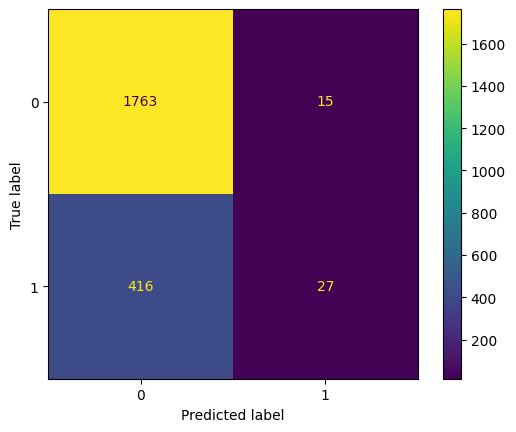

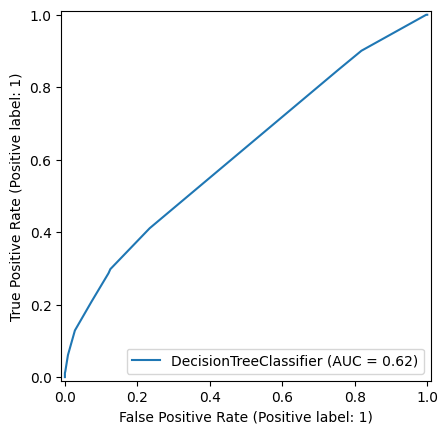

In [23]:
# Construct and plot the confusion matrix for the pruned tree (clf_pruned model)
clf_pruned_cm_test = confusion_matrix(y_test, y_pred_clf_pruned, labels = clf_pruned.classes_)
disp = ConfusionMatrixDisplay(clf_pruned_cm_test,display_labels = clf_pruned.classes_)
disp.plot(values_format = '.0f')

# Produce the classification report for the prunded tree (clf_pruned model)
print("clf_pruned tree report \n", classification_report(y_test, y_pred_clf_pruned))

# Plot the ROC curve for the pruned treen
clf_pruned_Roc = RocCurveDisplay.from_estimator(clf_pruned, X1_test, y_test)


In [24]:
#create new a Decision Tree model
clf = DecisionTreeClassifier()

#create a dictionary of all values we want to test for n_neighbors and distances
param_grid = {'max_depth': np.arange(1, 32), 'criterion': ['gini', 'entropy', 'log_loss'] }

#use GridsearchCV to test all values for n_neighbors
clf_gscv = GridSearchCV(clf, param_grid, cv=5, scoring = 'f1')

#fit model to data
clf_gscv.fit(X1_train, y_train)

# Display the best parameters from the hyperparameter tuning process
clf_gscv.best_params_


{'criterion': 'entropy', 'max_depth': np.int64(19)}

              precision    recall  f1-score   support

           0       0.88      0.90      0.89      1778
           1       0.54      0.49      0.51       443

    accuracy                           0.81      2221
   macro avg       0.71      0.69      0.70      2221
weighted avg       0.81      0.81      0.81      2221



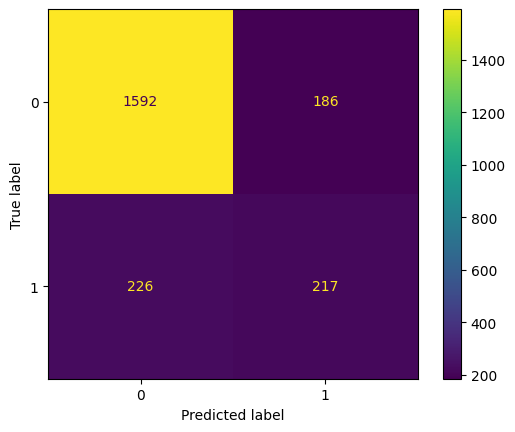

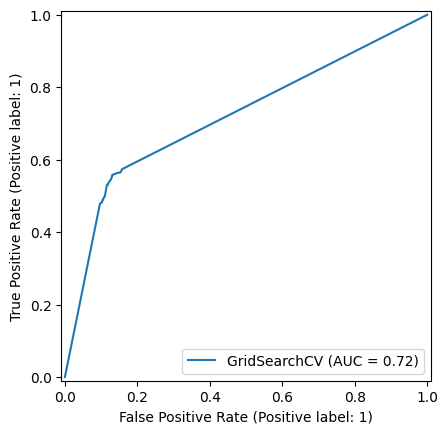

In [25]:
#Predict the response for test dataset
y_pred_clf_gscv = clf_gscv.predict(X1_test)

#print the new classification report
print(classification_report(y_test, y_pred_clf_gscv))

# Construct and plot the confusion matrix for the pruned tree (clf_pruned model)
clf_gscv_cm = confusion_matrix(y_test, y_pred_clf_gscv, labels = clf_gscv.classes_)
disp = ConfusionMatrixDisplay(clf_gscv_cm, display_labels = clf_gscv.classes_)
disp.plot (values_format = '.0f')

# Plot the ROC curve for the pruned treen
clf_gscv_Roc = RocCurveDisplay.from_estimator(clf_gscv, X1_test, y_test)
